# Guide II: Interpreting Predictions & Understanding Limits

## Time-Series Forecasting and Model Evaluation

**Real-World Application: Predicting Global Health Trends**

This notebook demonstrates how data science can support decision-making on critical social issues. We'll use time-series analysis to evaluate prediction reliability for urgent problems like disease prevention, poverty reduction, or environmental monitoring.

By understanding model limitations and communicating uncertainty honestly, organizations can make better decisions about resource allocation, policy interventions, and impact measurement.


## 1. Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load and Prepare Time-Series Data


In [2]:
# Create a synthetic time-series dataset
np.random.seed(42)
dates = pd.date_range('2020-01-01', periods=200, freq='D')



In [3]:
dates

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04',
               '2020-01-05', '2020-01-06', '2020-01-07', '2020-01-08',
               '2020-01-09', '2020-01-10',
               ...
               '2020-07-09', '2020-07-10', '2020-07-11', '2020-07-12',
               '2020-07-13', '2020-07-14', '2020-07-15', '2020-07-16',
               '2020-07-17', '2020-07-18'],
              dtype='datetime64[ns]', length=200, freq='D')

In [4]:
trend = np.linspace(0, 50, 200)
trend

array([ 0.        ,  0.25125628,  0.50251256,  0.75376884,  1.00502513,
        1.25628141,  1.50753769,  1.75879397,  2.01005025,  2.26130653,
        2.51256281,  2.7638191 ,  3.01507538,  3.26633166,  3.51758794,
        3.76884422,  4.0201005 ,  4.27135678,  4.52261307,  4.77386935,
        5.02512563,  5.27638191,  5.52763819,  5.77889447,  6.03015075,
        6.28140704,  6.53266332,  6.7839196 ,  7.03517588,  7.28643216,
        7.53768844,  7.78894472,  8.04020101,  8.29145729,  8.54271357,
        8.79396985,  9.04522613,  9.29648241,  9.54773869,  9.79899497,
       10.05025126, 10.30150754, 10.55276382, 10.8040201 , 11.05527638,
       11.30653266, 11.55778894, 11.80904523, 12.06030151, 12.31155779,
       12.56281407, 12.81407035, 13.06532663, 13.31658291, 13.5678392 ,
       13.81909548, 14.07035176, 14.32160804, 14.57286432, 14.8241206 ,
       15.07537688, 15.32663317, 15.57788945, 15.82914573, 16.08040201,
       16.33165829, 16.58291457, 16.83417085, 17.08542714, 17.33

In [5]:
seasonality = 10 * np.sin(np.arange(200) * 2 * np.pi / 30)
seasonality

array([ 0.00000000e+00,  2.07911691e+00,  4.06736643e+00,  5.87785252e+00,
        7.43144825e+00,  8.66025404e+00,  9.51056516e+00,  9.94521895e+00,
        9.94521895e+00,  9.51056516e+00,  8.66025404e+00,  7.43144825e+00,
        5.87785252e+00,  4.06736643e+00,  2.07911691e+00,  5.66553890e-15,
       -2.07911691e+00, -4.06736643e+00, -5.87785252e+00, -7.43144825e+00,
       -8.66025404e+00, -9.51056516e+00, -9.94521895e+00, -9.94521895e+00,
       -9.51056516e+00, -8.66025404e+00, -7.43144825e+00, -5.87785252e+00,
       -4.06736643e+00, -2.07911691e+00, -1.13310778e-14,  2.07911691e+00,
        4.06736643e+00,  5.87785252e+00,  7.43144825e+00,  8.66025404e+00,
        9.51056516e+00,  9.94521895e+00,  9.94521895e+00,  9.51056516e+00,
        8.66025404e+00,  7.43144825e+00,  5.87785252e+00,  4.06736643e+00,
        2.07911691e+00,  3.67394040e-15, -2.07911691e+00, -4.06736643e+00,
       -5.87785252e+00, -7.43144825e+00, -8.66025404e+00, -9.51056516e+00,
       -9.94521895e+00, -

In [6]:
noise = np.random.normal(0, 5, 200)
noise

array([  2.48357077,  -0.69132151,   3.23844269,   7.61514928,
        -1.17076687,  -1.17068478,   7.89606408,   3.83717365,
        -2.34737193,   2.71280022,  -2.31708846,  -2.32864877,
         1.20981136,  -9.56640122,  -8.62458916,  -2.81143765,
        -5.0641556 ,   1.57123666,  -4.54012038,  -7.06151851,
         7.32824384,  -1.1288815 ,   0.33764102,  -7.12374093,
        -2.72191362,   0.55461295,  -5.75496789,   1.87849009,
        -3.00319345,  -1.45846875,  -3.00853306,   9.26139092,
        -0.06748612,  -5.28855464,   4.11272456,  -6.10421825,
         1.04431798,  -9.79835062,  -6.64093024,   0.98430618,
         3.6923329 ,   0.85684141,  -0.57824141,  -1.50551848,
        -7.39260995,  -3.59922104,  -2.30319385,   5.28561113,
         1.71809145,  -8.81520078,   1.62041985,  -1.9254114 ,
        -3.38461   ,   3.05838144,   5.15499761,   4.6564006 ,
        -4.19608762,  -1.54606188,   1.65631716,   4.87772564,
        -2.39587119,  -0.92829488,  -5.53167487,  -5.98

In [7]:
values = 100 + trend + seasonality + noise

data = pd.DataFrame({
    'date': dates,
    'value': values
})

data.set_index('date', inplace=True)
data

,value
date,
2020-01-01,102.483571
2020-01-02,101.639052
2020-01-03,107.808322
2020-01-04,114.246771
2020-01-05,107.265707
...,...
2020-07-14,150.921562
2020-07-15,142.747827
2020-07-16,146.198747


Dataset Overview:
Shape: (200, 1)
Date range: 2020-01-01 00:00:00 to 2020-07-18 00:00:00

First few rows:
                 value
date                  
2020-01-01  102.483571
2020-01-02  101.639052
2020-01-03  107.808322
2020-01-04  114.246771
2020-01-05  107.265707

Basic statistics:
            value
count  200.000000
mean   125.174584
std     16.915901
min     88.709935
25%    111.867562
50%    125.834403
75%    137.355549
max    159.703392


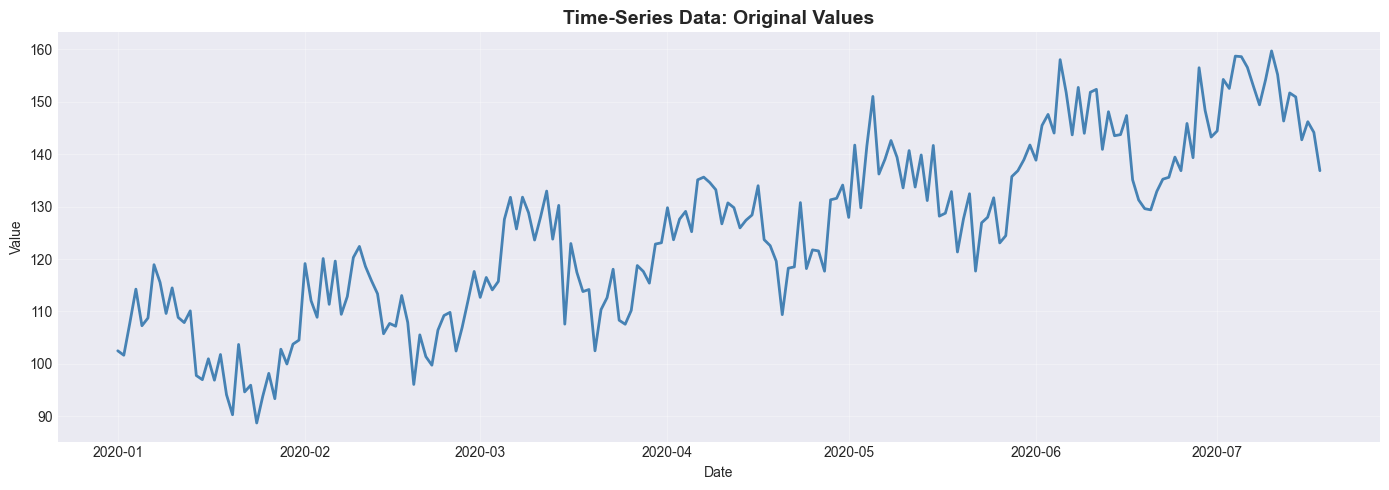

In [8]:
print("Dataset Overview:")
print(f"Shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")
print(f"\nFirst few rows:")
print(data.head())
print(f"\nBasic statistics:")
print(data.describe())

# Visualize the original time-series
plt.figure(figsize=(14, 5))
plt.plot(data.index, data['value'], linewidth=2, color='steelblue')
plt.title('Time-Series Data: Original Values', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Create lagged features for prediction
def create_lagged_features(data, lag=5):
    """Create lagged features for time-series modeling."""
    df = data.copy()
    
    for i in range(1, lag + 1):
        df[f'lag_{i}'] = df['value'].shift(i)
    
    df = df.dropna()
    return df

# Create lagged features
lag_value = 5
data_features = create_lagged_features(data[['value']], lag=lag_value)

print(f"Features created with lag={lag_value}")
print(f"Shape after creating features: {data_features.shape}")
print(f"\nFirst few rows with lagged features:")
print(data_features.head())

# Prepare X and y
X = data_features.drop('value', axis=1).values
y = data_features['value'].values

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")


Features created with lag=5
Shape after creating features: (195, 6)

First few rows with lagged features:
                 value       lag_1       lag_2       lag_3       lag_4  \
date                                                                     
2020-01-06  108.745851  107.265707  114.246771  107.808322  101.639052   
2020-01-07  118.914167  108.745851  107.265707  114.246771  107.808322   
2020-01-08  115.541187  118.914167  108.745851  107.265707  114.246771   
2020-01-09  109.607897  115.541187  118.914167  108.745851  107.265707   
2020-01-10  114.484672  109.607897  115.541187  118.914167  108.745851   

                 lag_5  
date                    
2020-01-06  102.483571  
2020-01-07  101.639052  
2020-01-08  107.808322  
2020-01-09  114.246771  
2020-01-10  107.265707  

X shape: (195, 5)
y shape: (195,)


In [10]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Plot actual values
fig.add_trace(go.Scatter(
    x=data_features.index,
    y=data_features['value'],
    mode='lines',
    name='Actual Value',
    line=dict(color='steelblue', width=2)
))

# Plot lagged features
colors = ['red', 'orange', 'green', 'purple', 'brown']
for i in range(1, lag_value + 1):
    fig.add_trace(go.Scatter(
        x=data_features.index,
        y=data_features[f'lag_{i}'],
        mode='lines',
        name=f'Lag {i}',
        line=dict(color=colors[i-1], width=1.5, dash='dash'),
        opacity=0.7
    ))

# Update layout
fig.update_layout(
    title='Time-Series Data: Actual Values and Lagged Features',
    xaxis_title='Date',
    yaxis_title='Value',
    hovermode='x unified',
    height=600,
    template='plotly_white',
    font=dict(size=11),
    legend=dict(
        yanchor='top',
        y=0.99,
        xanchor='left',
        x=0.01
    )
)

fig.show()

## 3. Train a Time-Series Model

We'll train a simple linear regression model on the training data to make predictions.


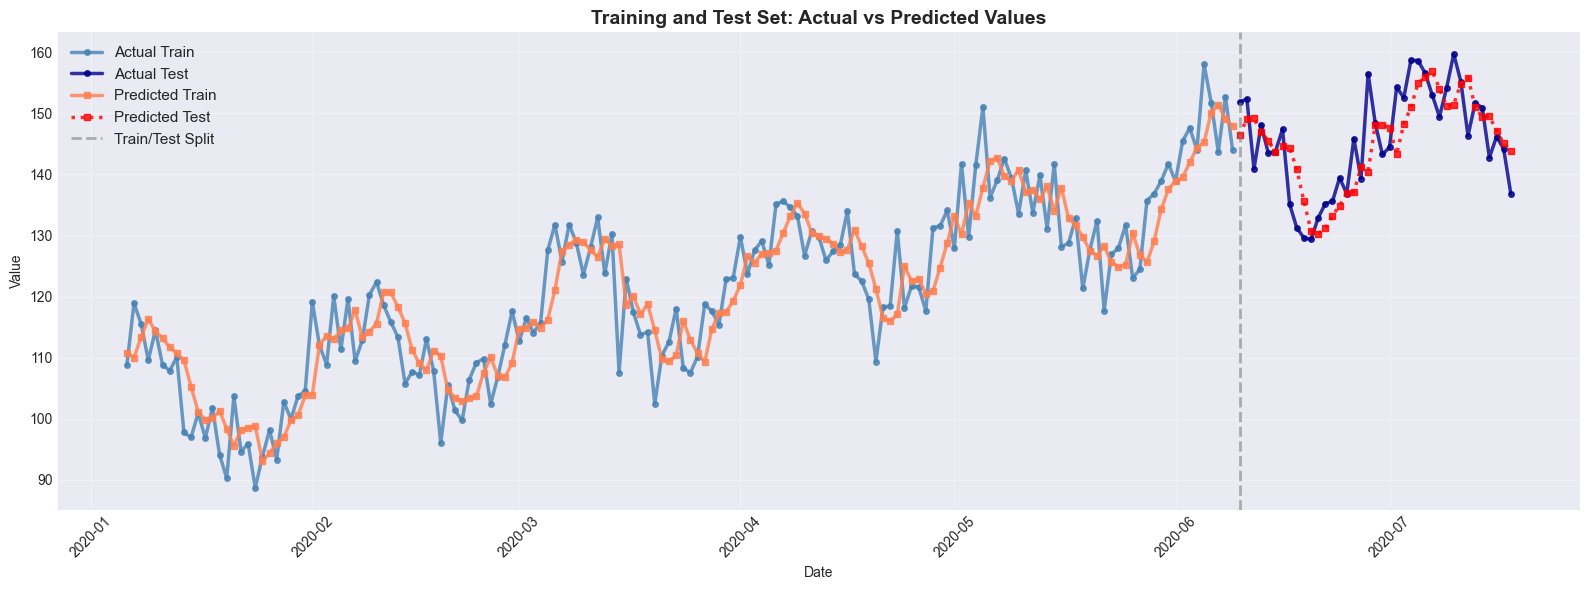

Training period: 2020-01-06 to 2020-06-09
Test period: 2020-06-10 to 2020-07-18
Split date: 2020-06-10


In [13]:
# Split data into train and test sets
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Combine train and test data for unified visualization
plt.figure(figsize=(16, 6))

# Plot actual values
plt.plot(data_features.index[:len(y_train)], y_train, 
         label='Actual Train', linewidth=2.5, color='steelblue', marker='o', markersize=4, alpha=0.8)
plt.plot(data_features.index[len(y_train):], y_test, 
         label='Actual Test', linewidth=2.5, color='darkblue', marker='o', markersize=4, alpha=0.8)

# Plot predictions
plt.plot(data_features.index[:len(y_train)], y_pred_train, 
         label='Predicted Train', linewidth=2.5, color='coral', marker='s', markersize=4, alpha=0.8)
plt.plot(data_features.index[len(y_train):], y_pred_test, 
         label='Predicted Test', linewidth=2.5, color='red', marker='s', markersize=4, 
         linestyle=':', alpha=0.8)

# Add vertical line at train/test split
split_date = data_features.index[len(y_train)]
plt.axvline(x=split_date, color='gray', linestyle='--', linewidth=2, alpha=0.6, label='Train/Test Split')

plt.title('Training and Test Set: Actual vs Predicted Values', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print date range information
print(f"Training period: {data_features.index[0].date()} to {data_features.index[len(y_train)-1].date()}")
print(f"Test period: {data_features.index[len(y_train)].date()} to {data_features.index[-1].date()}")
print(f"Split date: {split_date.date()}")


## 4. Calculate MSE and RMSE

**Mean Squared Error (MSE)** and **Root Mean Squared Error (RMSE)** measure average prediction error.

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

$$RMSE = \sqrt{MSE}$$

- **MSE**: Emphasizes larger errors (quadratic penalty)
- **RMSE**: Returns to original scale, more interpretable
- **Limitation**: Sensitive to outliers due to squaring


## 5. Calculate WAPE and MAPE

**Mean Absolute Percentage Error (MAPE)** and **Weighted Absolute Percentage Error (WAPE)** are percentage-based metrics.

$$MAPE = \frac{1}{n}\sum_{i=1}^{n}\frac{|y_i - \hat{y}_i|}{|y_i|} \times 100$$

$$WAPE = \frac{\sum|y_i - \hat{y}_i|}{\sum|y_i|} \times 100$$

- **MAPE**: Individual percentage errors averaged
- **WAPE**: Prevents extreme values from dominating
- **Advantage**: Scale-independent, easy to interpret
- **Limitation**: Undefined when actual=0; can be misleading with small values


In [16]:
# Define MAPE and WAPE functions
def calculate_mape(y_actual, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    mask = y_actual != 0
    mape = np.mean(np.abs((y_actual[mask] - y_pred[mask]) / y_actual[mask])) * 100
    return mape

def calculate_wape(y_actual, y_pred):
    """Calculate Weighted Absolute Percentage Error"""
    numerator = np.sum(np.abs(y_actual - y_pred))
    denominator = np.sum(np.abs(y_actual))
    if denominator == 0:
        return 0
    wape = (numerator / denominator) * 100
    return wape

# Calculate MSE and RMSE for train and test
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)

# Calculate MAE for train and test
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

# Calculate MAPE and WAPE for train and test
mape_train = calculate_mape(y_train, y_pred_train)
wape_train = calculate_wape(y_train, y_pred_train)
mape_test = calculate_mape(y_test, y_pred_test)
wape_test = calculate_wape(y_test, y_pred_test)

# Build summary metrics table
metrics_table = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'MAPE (%)', 'WAPE (%)'],
    'Train': [
        mse_train,
        rmse_train,
        mae_train,
        mape_train,
        wape_train
    ],
    'Test': [
        mse_test,
        rmse_test,
        mae_test,
        mape_test,
        wape_test
    ]
})

metrics_table = metrics_table.round(4)
print(metrics_table.to_string(index=False))

  Metric   Train    Test
     MSE 37.3177 32.6020
    RMSE  6.1088  5.7098
     MAE  4.8712  4.4161
MAPE (%)  4.0890  3.0329
WAPE (%)  4.0379  3.0311


In [18]:
# Calculate MAPE and WAPE
mape_train = calculate_mape(y_train, y_pred_train)
wape_train = calculate_wape(y_train, y_pred_train)

mape_test = calculate_mape(y_test, y_pred_test)
wape_test = calculate_wape(y_test, y_pred_test)

print("=" * 60)
print("MAPE & WAPE Metrics (Percentage-Based)")
print("=" * 60)
print(f"\nTraining Set:")
print(f"  MAPE: {mape_train:.2f}%")
print(f"  WAPE: {wape_train:.2f}%")

print(f"\nTest Set:")
print(f"  MAPE: {mape_test:.2f}%")
print(f"  WAPE: {wape_test:.2f}%")

# Summary table
metrics_summary = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAPE (%)', 'WAPE (%)'],
    'Train': [mse_train, rmse_train, mape_train, wape_train],
    'Test': [mse_test, rmse_test, mape_test, wape_test]
})

print("\n" + "=" * 60)
print("All Metrics Summary")
print("=" * 60)
print(metrics_summary.to_string(index=False))


MAPE & WAPE Metrics (Percentage-Based)

Training Set:
  MAPE: 4.09%
  WAPE: 4.04%

Test Set:
  MAPE: 3.03%
  WAPE: 3.03%

All Metrics Summary
  Metric     Train      Test
     MSE 37.317714 32.601999
    RMSE  6.108823  5.709816
MAPE (%)  4.089019  3.032948
WAPE (%)  4.037906  3.031093


## 6. Implement K-Fold Cross-Validation for Time-Series

Time-series k-fold cross-validation uses **forward-chaining** to respect temporal order and avoid data leakage.

**Key principle:** Train on earlier data, test on later data. Never train on future data!


In [19]:
# Implement TimeSeriesSplit for k-fold cross-validation
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Store results for each fold
fold_results = []
fold_metrics = {
    'mse': [],
    'rmse': [],
    'mape': [],
    'wape': [],
    'fold': []
}

print("=" * 60)
print(f"Time-Series {n_splits}-Fold Cross-Validation")
print("=" * 60)

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X)):
    # Split data
    X_cv_train, X_cv_test = X[train_idx], X[test_idx]
    y_cv_train, y_cv_test = y[train_idx], y[test_idx]
    
    # Train model
    model_cv = LinearRegression()
    model_cv.fit(X_cv_train, y_cv_train)
    
    # Make predictions
    y_cv_pred = model_cv.predict(X_cv_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_cv_test, y_cv_pred)
    rmse = np.sqrt(mse)
    mape = calculate_mape(y_cv_test, y_cv_pred)
    wape = calculate_wape(y_cv_test, y_cv_pred)
    
    # Store results
    fold_metrics['mse'].append(mse)
    fold_metrics['rmse'].append(rmse)
    fold_metrics['mape'].append(mape)
    fold_metrics['wape'].append(wape)
    fold_metrics['fold'].append(fold_idx + 1)
    
    fold_results.append({
        'fold': fold_idx + 1,
        'train_size': len(train_idx),
        'test_size': len(test_idx),
        'mse': mse,
        'rmse': rmse,
        'mape': mape,
        'wape': wape
    })
    
    print(f"\nFold {fold_idx + 1}:")
    print(f"  Train size: {len(train_idx)}, Test size: {len(test_idx)}")
    print(f"  MSE:  {mse:.4f}, RMSE: {rmse:.4f}")
    print(f"  MAPE: {mape:.2f}%, WAPE: {wape:.2f}%")

# Create results DataFrame
cv_results_df = pd.DataFrame(fold_results)

print("\n" + "=" * 60)
print("Cross-Validation Results Summary")
print("=" * 60)
print(cv_results_df.to_string(index=False))


Time-Series 5-Fold Cross-Validation

Fold 1:
  Train size: 35, Test size: 32
  MSE:  37.8084, RMSE: 6.1489
  MAPE: 3.88%, WAPE: 3.91%

Fold 2:
  Train size: 67, Test size: 32
  MSE:  41.0504, RMSE: 6.4071
  MAPE: 4.09%, WAPE: 3.98%

Fold 3:
  Train size: 99, Test size: 32
  MSE:  46.9312, RMSE: 6.8506
  MAPE: 4.31%, WAPE: 4.35%

Fold 4:
  Train size: 131, Test size: 32
  MSE:  36.1517, RMSE: 6.0126
  MAPE: 3.65%, WAPE: 3.61%

Fold 5:
  Train size: 163, Test size: 32
  MSE:  36.3392, RMSE: 6.0282
  MAPE: 3.22%, WAPE: 3.22%

Cross-Validation Results Summary
 fold  train_size  test_size       mse     rmse     mape     wape
    1          35         32 37.808421 6.148855 3.878562 3.910553
    2          67         32 41.050400 6.407059 4.093695 3.984449
    3          99         32 46.931195 6.850635 4.307994 4.349341
    4         131         32 36.151720 6.012630 3.645222 3.606056
    5         163         32 36.339197 6.028200 3.219599 3.220143


## 7. Visualize Prediction Errors


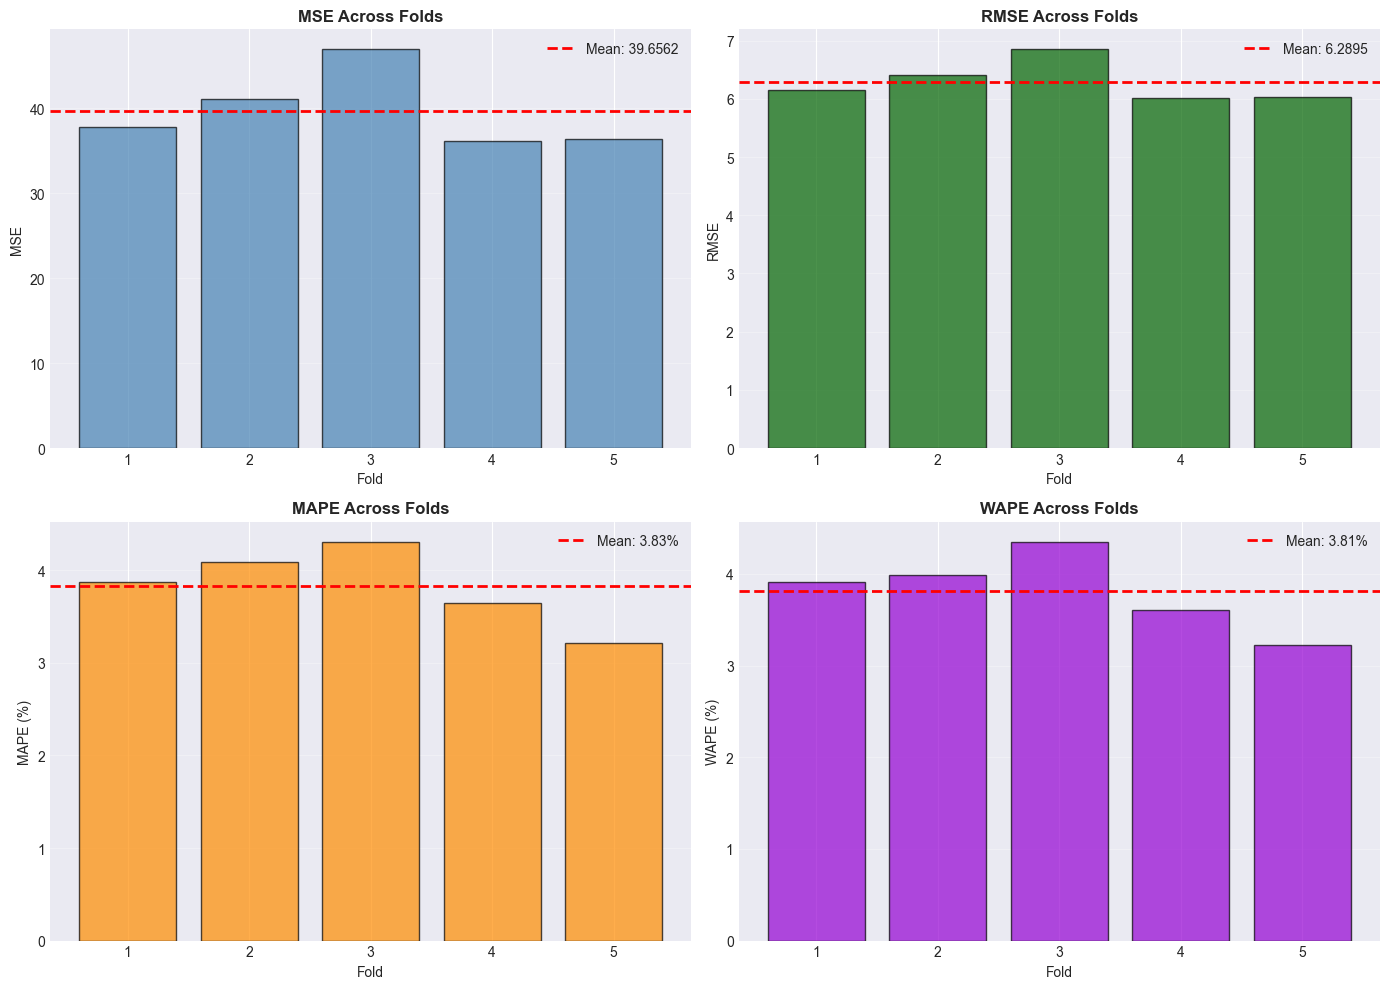

In [21]:
# Visualize errors across folds
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MSE across folds
axes[0, 0].bar(cv_results_df['fold'], cv_results_df['mse'], 
               color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axhline(cv_results_df['mse'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {cv_results_df["mse"].mean():.4f}')
axes[0, 0].set_title('MSE Across Folds', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Fold')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: RMSE across folds
axes[0, 1].bar(cv_results_df['fold'], cv_results_df['rmse'], 
               color='darkgreen', alpha=0.7, edgecolor='black')
axes[0, 1].axhline(cv_results_df['rmse'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {cv_results_df["rmse"].mean():.4f}')
axes[0, 1].set_title('RMSE Across Folds', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Fold')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: MAPE across folds
axes[1, 0].bar(cv_results_df['fold'], cv_results_df['mape'], 
               color='darkorange', alpha=0.7, edgecolor='black')
axes[1, 0].axhline(cv_results_df['mape'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {cv_results_df["mape"].mean():.2f}%')
axes[1, 0].set_title('MAPE Across Folds', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('MAPE (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: WAPE across folds
axes[1, 1].bar(cv_results_df['fold'], cv_results_df['wape'], 
               color='darkviolet', alpha=0.7, edgecolor='black')
axes[1, 1].axhline(cv_results_df['wape'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {cv_results_df["wape"].mean():.2f}%')
axes[1, 1].set_title('WAPE Across Folds', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Fold')
axes[1, 1].set_ylabel('WAPE (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Confidence Intervals & Interactive Plotly Visualization

**Confidence intervals** show the range where predictions likely fall. A 95% confidence interval means we expect the true value to be in this range 95% of the time.

This helps you understand **how certain** your predictions are, not just what they are.


In [22]:
from prophet import Prophet

# Split data into train and test sets
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Train linear regression model for one-step-ahead predictions
model = LinearRegression()
model.fit(X_train, y_train)

# Predict one step at a time
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Prepare data for Prophet (requires 'ds' and 'y' columns)
prophet_data = data.reset_index()
prophet_data.columns = ['ds', 'y']

# Initialize and fit Prophet model
prophet_model = Prophet()
prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
prophet_model.fit(prophet_data.iloc[:split_idx + lag_value])  # train only on training period

# Predict one step at a time for test period
test_start_idx = split_idx
prophet_pred_test = []
prophet_lower_test = []
prophet_upper_test = []

for i in range(len(y_test)):
    future = prophet_model.make_future_dataframe(periods=i + 1)
    forecast = prophet_model.predict(future)
    prophet_pred_test.append(forecast['yhat'].iloc[-1])
    prophet_lower_test.append(forecast['yhat_lower'].iloc[-1])
    prophet_upper_test.append(forecast['yhat_upper'].iloc[-1])

prophet_pred_test = np.array(prophet_pred_test)
prophet_lower_test = np.array(prophet_lower_test)
prophet_upper_test = np.array(prophet_upper_test)

19:28:46 - cmdstanpy - INFO - Chain [1] start processing
19:28:46 - cmdstanpy - INFO - Chain [1] done processing


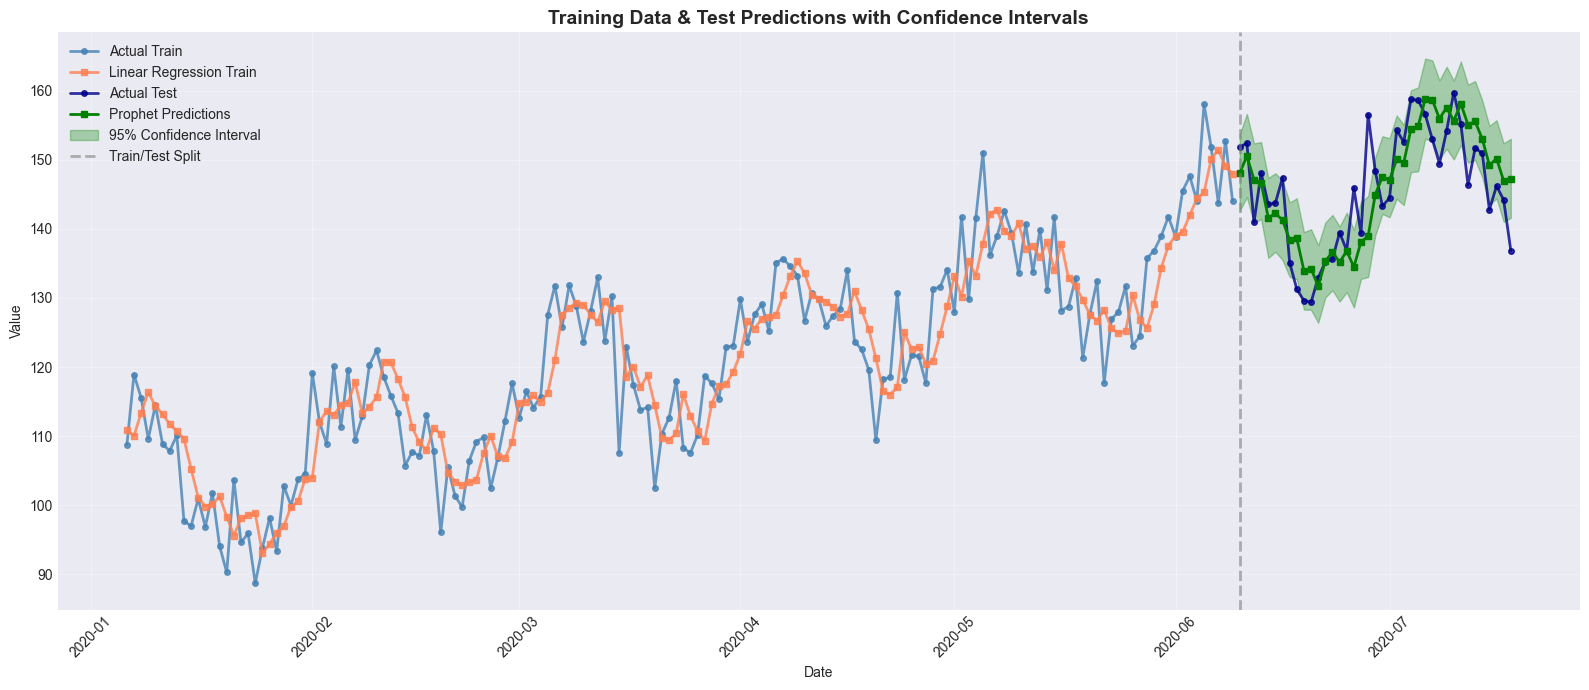

In [24]:
fig, ax = plt.subplots(figsize=(16, 7))

# Plot training actual values
ax.plot(data_features.index[:len(y_train)], y_train,
    'o-', label='Actual Train', linewidth=2, color='steelblue', markersize=4, alpha=0.8)

# Plot training predictions
ax.plot(data_features.index[:len(y_train)], y_pred_train,
    's-', label='Linear Regression Train', linewidth=2, color='coral', markersize=4, alpha=0.8)

# Plot test actual values
ax.plot(data_features.index[test_start_idx:test_start_idx + len(y_test)], y_test,
    'o-', label='Actual Test', linewidth=2, color='darkblue', markersize=4, alpha=0.8)

# Plot Prophet predictions on test set
ax.plot(data_features.index[test_start_idx:test_start_idx + len(y_test)], prophet_pred_test,
    's-', label='Prophet Predictions', linewidth=2, color='green', markersize=4)

# Add confidence interval as shaded area
ax.fill_between(data_features.index[test_start_idx:test_start_idx + len(y_test)],
        prophet_lower_test, prophet_upper_test,
        alpha=0.3, color='green', label='95% Confidence Interval')

# Add vertical line at train/test split
ax.axvline(x=data_features.index[test_start_idx], color='gray', linestyle='--',
       linewidth=2, alpha=0.6, label='Train/Test Split')

ax.set_title('Training Data & Test Predictions with Confidence Intervals', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
